# Imbalance Handling Strategies

This notebook compares four imbalance-handling strategies for `LogisticRegression` on the Car Evaluation dataset, keeping the model, the split, and the encoding constant across all four. The goal is to see which strategy actually helps the minority classes (`good`, `vgood`), and to test whether SMOTEN — designed for categorical data — outperforms classical SMOTE on ordinal-encoded features.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from imblearn.over_sampling import SMOTE, SMOTEN
from imblearn.pipeline import Pipeline

RANDOM_STATE = 42

Load the dataset and produce a stratified 80/20 split. The split runs once so `X_test` stays identical for every strategy.

In [15]:
df = pd.read_csv('dataset/cars_classification_dataset.csv')

X_raw = df.drop('car', axis=1)
y = df['car']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train size: {len(X_train_raw)} | Test size: {len(X_test_raw)}')
print('\nClass distribution in y_train:')
print(y_train.value_counts())

Train size: 1382 | Test size: 346

Class distribution in y_train:
car
unacc    968
acc      307
good      55
vgood     52
Name: count, dtype: int64


Ordinal-encode the six categorical features using their natural ordering. The encoder is fit on the training set and reused on the test set — no leakage.

In [16]:
ordinal_categories = [
    ['low', 'med', 'high', 'vhigh'],
    ['low', 'med', 'high', 'vhigh'],
    ['two', 'three', 'four', '5more'],
    ['two', 'four', 'more'],
    ['small', 'med', 'big'],
    ['low', 'med', 'high'],
]

encoder = OrdinalEncoder(categories=ordinal_categories)

X_train_ord = pd.DataFrame(
    encoder.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index,
)
X_test_ord = pd.DataFrame(
    encoder.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index,
)

X_train_ord.head()

,buying,maint,doors,persons,lug_boot,safety
1381,1.0,2.0,1.0,2.0,1.0,1.0
912,2.0,2.0,2.0,1.0,1.0,0.0
1661,1.0,3.0,3.0,2.0,1.0,2.0
680,1.0,0.0,0.0,1.0,1.0,2.0
310,3.0,1.0,2.0,0.0,1.0,1.0


### Strategy 1 — Baseline

No resampling, no reweighting. Shows what `LogisticRegression` does when left alone on a skewed target.

In [17]:
baseline_pipeline = Pipeline([
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

baseline_pipeline.fit(X_train_ord, y_train)

,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](4,)","['acc','good','unacc','vgood']"
feature_names_in_,"ndarray[object](6,)","['buying','maint','doors','persons','lug_boot','safety']"
n_features_in_,int,6
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'


Per-class metrics and confusion matrix for the baseline.

              precision    recall  f1-score   support

         acc      0.698     0.571     0.629        77
        good      0.667     0.429     0.522        14
       unacc      0.876     0.938     0.906       242
       vgood      0.667     0.769     0.714        13

    accuracy                          0.829       346
   macro avg      0.727     0.677     0.693       346
weighted avg      0.820     0.829     0.822       346



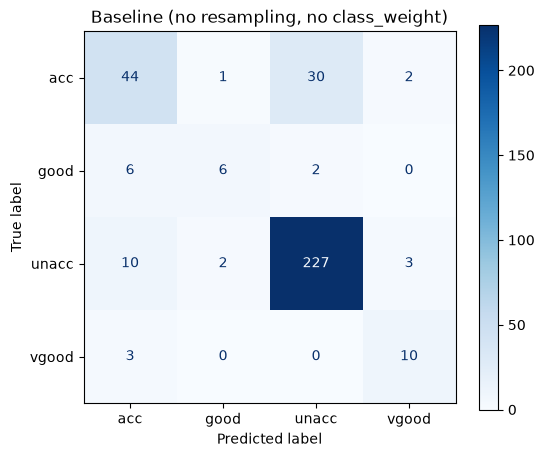

In [18]:
y_pred_baseline = baseline_pipeline.predict(X_test_ord)

print(classification_report(y_test, y_pred_baseline, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_baseline,
    labels=baseline_pipeline.classes_,
    cmap='Blues',
    ax=ax,
)
ax.set_title('Baseline (no resampling, no class_weight)')
plt.show()

### Strategy 2 — Classical SMOTE

Load a pre-trained pipeline (`OrdinalEncoder` → `SMOTE` → `LogisticRegression`). SMOTE creates synthetic minority samples by linear interpolation between k nearest neighbours in the encoded feature space.

In [19]:
import joblib

smote_pipeline = joblib.load('log_reg_model.joblib')
smote_pipeline

,steps,"[('encoder', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](4,)","['acc','good','unacc','vgood']"
feature_names_in_,"ndarray[object](6,)","['buying','maint','doors','persons','lug_boot','safety']"
n_features_in_,int,6
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['low', 'med', ...], ['low', 'med', ...], ...]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'


Per-class metrics and confusion matrix for SMOTE. The pipeline takes raw strings — the encoder step is inside.

              precision    recall  f1-score   support

         acc      0.629     0.792     0.701        77
        good      0.583     1.000     0.737        14
       unacc      0.946     0.798     0.865       242
       vgood      0.571     0.923     0.706        13

    accuracy                          0.809       346
   macro avg      0.682     0.878     0.752       346
weighted avg      0.847     0.809     0.818       346



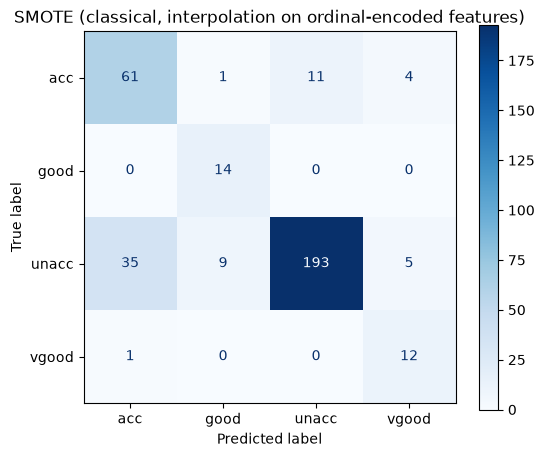

In [20]:
y_pred_smote = smote_pipeline.predict(X_test_raw)

print(classification_report(y_test, y_pred_smote, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_smote,
    labels=smote_pipeline.classes_,
    cmap='Blues',
    ax=ax,
)
ax.set_title('SMOTE (classical, interpolation on ordinal-encoded features)')
plt.show()

### Strategy 3 — SMOTEN

SMOTEN is designed for purely categorical features: instead of interpolating, it takes the *mode* of the k nearest minority neighbours per feature. In theory it respects the discrete nature of the data better than classical SMOTE.

In [21]:
smoten_pipeline = Pipeline([
    ('smoten', SMOTEN(random_state=RANDOM_STATE)),
    ('clf', LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

smoten_pipeline.fit(X_train_ord, y_train)

,steps,"[('smoten', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](4,)","['acc','good','unacc','vgood']"
feature_names_in_,"ndarray[object](6,)","['buying','maint','doors','persons','lug_boot','safety']"
n_features_in_,int,6
,random_state,42
,categorical_encoder,None
,sampling_strategy,'auto'


Per-class metrics and confusion matrix for SMOTEN.

              precision    recall  f1-score   support

         acc      0.624     0.818     0.708        77
        good      0.481     0.929     0.634        14
       unacc      0.959     0.773     0.856       242
       vgood      0.522     0.923     0.667        13

    accuracy                          0.795       346
   macro avg      0.646     0.861     0.716       346
weighted avg      0.849     0.795     0.807       346



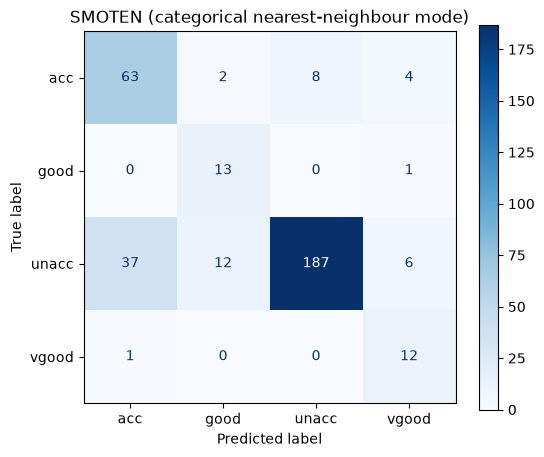

In [22]:
y_pred_smoten = smoten_pipeline.predict(X_test_ord)

print(classification_report(y_test, y_pred_smoten, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_smoten,
    labels=smoten_pipeline.classes_,
    cmap='Blues',
    ax=ax,
)
ax.set_title('SMOTEN (categorical nearest-neighbour mode)')
plt.show()

### Strategy 4 — `class_weight='balanced'`

No data synthesis. The loss is reweighted internally so mistakes on rare classes cost more. The weight per class is computed as `n_samples / (n_classes * n_samples_per_class)`.

In [23]:
class_weight_pipeline = Pipeline([
    ('clf', LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced',
    )),
])

class_weight_pipeline.fit(X_train_ord, y_train)

,steps,"[('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[object](4,)","['acc','good','unacc','vgood']"
feature_names_in_,"ndarray[object](6,)","['buying','maint','doors','persons','lug_boot','safety']"
n_features_in_,int,6
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000


Per-class metrics and confusion matrix for `class_weight='balanced'`.

              precision    recall  f1-score   support

         acc      0.649     0.792     0.713        77
        good      0.483     1.000     0.651        14
       unacc      0.950     0.789     0.862       242
       vgood      0.545     0.923     0.686        13

    accuracy                          0.803       346
   macro avg      0.657     0.876     0.728       346
weighted avg      0.849     0.803     0.814       346



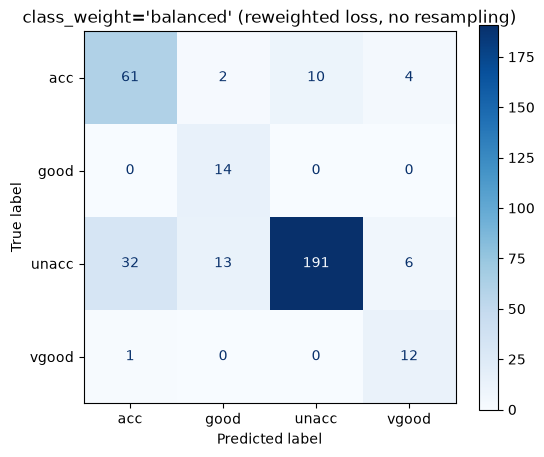

In [24]:
y_pred_cw = class_weight_pipeline.predict(X_test_ord)

print(classification_report(y_test, y_pred_cw, digits=3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cw,
    labels=class_weight_pipeline.classes_,
    cmap='Blues',
    ax=ax,
)
ax.set_title("class_weight='balanced' (reweighted loss, no resampling)")
plt.show()

In [25]:
from sklearn.metrics import roc_auc_score

model_map = {
    'Baseline': (baseline_pipeline, X_test_ord),
    'SMOTE': (smote_pipeline, X_test_raw),
    'SMOTEN': (smoten_pipeline, X_test_ord),
    "class_weight='balanced'": (class_weight_pipeline, X_test_ord),
}

class_order = list(baseline_pipeline.classes_)
probas = {}
rows = []

for name, (model, X_te) in model_map.items():
    y_prob = model.predict_proba(X_te)
    probas[name] = y_prob

    per_class_auc = roc_auc_score(
        y_test, y_prob,
        multi_class='ovr',
        average=None,
        labels=class_order,
    )
    macro_auc = roc_auc_score(
        y_test, y_prob,
        multi_class='ovr',
        average='macro',
        labels=class_order,
    )

    row = {'Strategy': name}
    for cls, auc in zip(class_order, per_class_auc):
        row[f'AUC {cls}'] = auc
    row['AUC macro'] = macro_auc
    rows.append(row)

auc_df = pd.DataFrame(rows).set_index('Strategy').round(4)
auc_df

,AUC acc,AUC good,AUC unacc,AUC vgood,AUC macro
Strategy,,,,,
Baseline,0.9107,0.9815,0.9293,0.9859,0.9519
SMOTE,0.9053,0.9852,0.9168,0.9864,0.9484
SMOTEN,0.8988,0.9800,0.9137,0.9868,0.9448
class_weight='balanced',0.9040,0.9826,0.9131,0.9845,0.9460


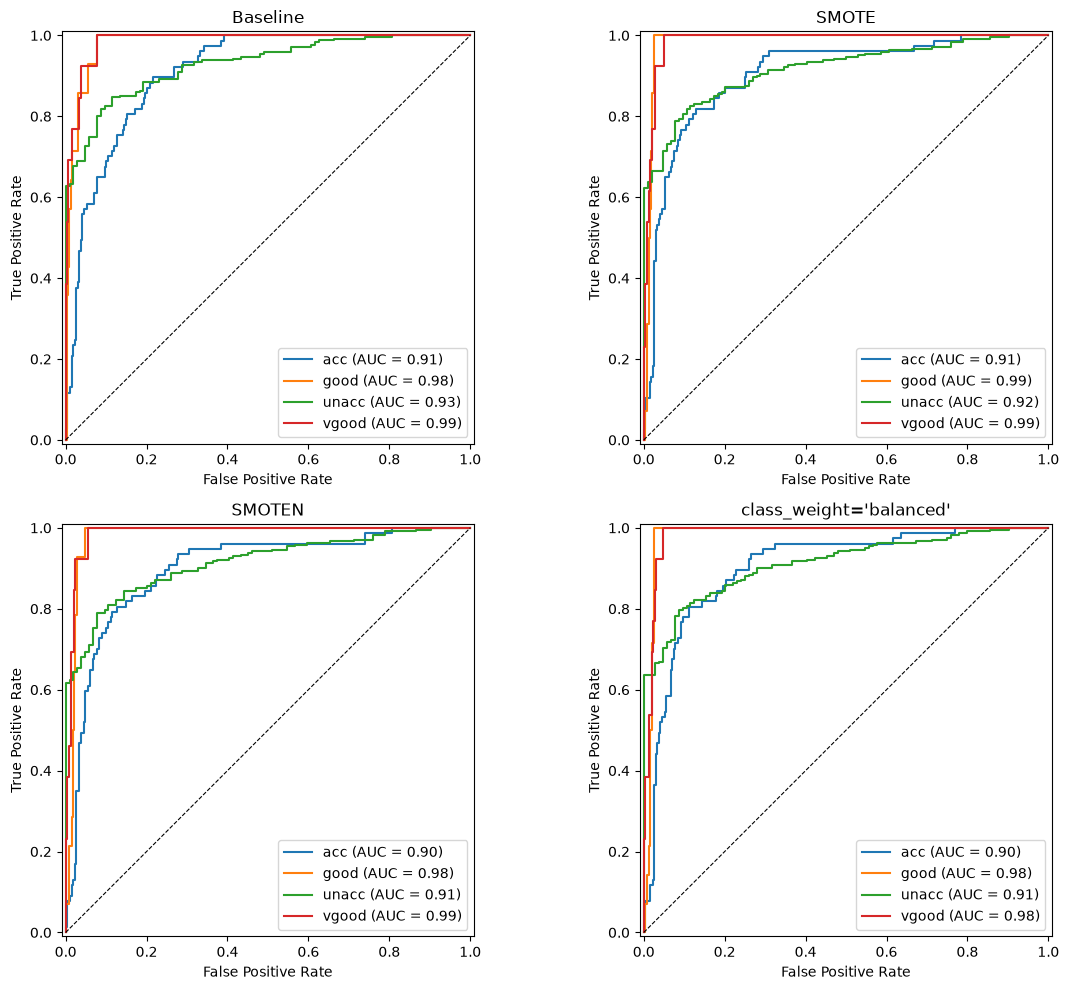

In [26]:
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=class_order)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, y_prob) in zip(axes.flatten(), probas.items()):
    for i, cls in enumerate(class_order):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],
            y_prob[:, i],
            name=cls,
            ax=ax,
        )
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8)
    ax.set_title(name)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')

plt.tight_layout()
plt.show()

## Synthesis

### Overall metrics

| Strategy | Accuracy | Macro F1 | Weighted F1 |
|---|---|---|---|
| Baseline | 0.829 | 0.693 | 0.822 |
| SMOTE | 0.809 | 0.752 | 0.818 |
| SMOTEN | 0.795 | 0.716 | 0.807 |
| class_weight='balanced' | 0.803 | 0.728 | 0.814 |

### Per-class F1

| Strategy | acc | good | unacc | vgood |
|---|---|---|---|---|
| Baseline | 0.629 | 0.522 | 0.906 | 0.714 |
| SMOTE | 0.701 | 0.737 | 0.865 | 0.706 |
| SMOTEN | 0.708 | 0.634 | 0.856 | 0.667 |
| class_weight | 0.713 | 0.651 | 0.862 | 0.686 |

### Per-class recall (minority-class story)

| Strategy | acc | good | unacc | vgood |
|---|---|---|---|---|
| Baseline | 0.571 | 0.429 | 0.938 | 0.769 |
| SMOTE | 0.792 | 1.000 | 0.798 | 0.923 |
| SMOTEN | 0.818 | 0.929 | 0.773 | 0.923 |
| class_weight | 0.792 | 1.000 | 0.789 | 0.923 |

### Observations

- The baseline scores the highest raw accuracy but the worst Macro F1. Accuracy is misleading here: `unacc` alone covers ~70% of the samples, so a model that never predicts anything else would already score around 0.70.
- Every imbalance-handling strategy trades some `unacc` recall for large gains on `good` and `vgood` — recall on `good` jumps from 0.429 up to 1.000 under SMOTE and `class_weight`.
- Classical SMOTE wins on Macro F1 and on both minority-class F1 scores. The theoretical concern about interpolating in ordinal-encoded space did not hurt performance here: the features are ordinal (not purely nominal), so interpolated midpoints still land in meaningful regions for a linear decision boundary.
- SMOTEN, despite being the algorithm designed for categorical features, ranks last among the imbalance-handling strategies. Mode-of-neighbours synthesis tends to produce near-duplicates of existing samples, adding little new geometric information on a dataset this small.
- `class_weight='balanced'` is a close second to SMOTE without inventing any data. It is a strong choice when reproducibility, auditability, or compliance concerns rule out synthetic samples.
- Final ranking by Macro F1: SMOTE > class_weight > SMOTEN > baseline.